#### MeanOnly Model replicating TimeView on Simulated Tumour Data

This implementation runs on data:
- with no unobserved heteroegeneity in the DGP,
- with no observational noise, 
- with equally spaced observations for all individuals. 

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

project_root = Path.cwd().parents[2]
sys.path.insert(0, str(project_root))

torch.set_default_dtype(torch.float64) 

# Functions needed for data generation
from scripts.shape_uncertainty.simulated_data.data_generator import WilkersonDGP
from scripts.shape_uncertainty.simulated_data.data_generator import generate_simulated_dataset
from scripts.shape_uncertainty.spline_basis.bspline_basis import build_knot_dictionary

# Functions needed to run MeanOnlyModel
from scripts.shape_uncertainty.model.model import MeanOnlyModel
from scripts.shape_uncertainty.model.model_training import Tuner
from scripts.shape_uncertainty.experiments.utilities import save_run, load_run

# Functions needed for shape extraction
from scripts.shape_uncertainty.model.model_inference import InferenceEngine
from scripts.shape_uncertainty.model.model_evaluation import ModelEvaluator
from scripts.shape_uncertainty.simulated_data.shape_ground_truth import get_analytic_shape_summary
from scripts.shape_uncertainty.shape_extraction.shape_distance import (
    exact_shape_sequence_match, shape_summary_distance,
    mean_shape_sequence_match, mean_shape_summary_distance,
)

# Helpers needed for plotting
from scripts.shape_uncertainty.experiments.plot_helpers import plot_individual_diagnostic

In [4]:
# Helper
def evaluate_extraction(engine, dataset, u1_rel, u2_rel, upsilon_rel_prune, do_prune):
    predicted = [engine.predict_mean_shape_summary(x)
                 for x in dataset.individual_covariates()]
    true = get_analytic_shape_summary(dataset, u1_rel, u2_rel, upsilon_rel_prune, do_prune)
    return {"predicted": predicted, "true": true,
            "accuracy": mean_shape_sequence_match(predicted, true),
            "distance": mean_shape_summary_distance(predicted, true, dataset.T)}

def _shape_states(summary):
    return [state for state, _ in summary]

def _transition_times(summary):
    return [f"{time:.4f}" for _, time in summary]

def per_patient_table(res, patients, T):
    rows = []
    for i in patients:
        pred, true = res["predicted"][i], res["true"][i]
        rows.append({
            "patient": i,
            "true_summary": _shape_states(true),
            "predicted_summary": _shape_states(pred),
            "match": exact_shape_sequence_match(pred, true),
            "distance": round(shape_summary_distance(pred, true, T), 3),
            "true_transitions": _transition_times(true),
            "predicted_transitions": _transition_times(pred),
        })
    return pd.DataFrame(rows)

#### Step 1: Generate a dataset

In [5]:
# Data-generating process
T = 1.0
ALPHA_G, ALPHA_D = 0.0, 0.0 # 0 = no unobserved heterogeneity
HYPERPARAMS = {"g0": 2.0, "d0": 180.0, "rho0": 10.0,
               "alpha_g": ALPHA_G, "alpha_d": ALPHA_D}

# Observation design 
NR_OBS = 20 # observations per individual
SIGMA = 0.0 # measurement-noise std
REGULAR = True
SEED = 42

# Dataset sizes
D_TRAIN, D_VAL, D_TEST = 2000, 1000, 1000
D_TOTAL = D_TRAIN + D_VAL + D_TEST

# Spline basis
NR_INTERIOR_KNOTS = 5 # B = K + 4 = 9, matches TimeView

In [6]:
# Specify the configuration for the data generating process 
dgp = WilkersonDGP(
        T=T, 
        hyperparams=HYPERPARAMS,
        ranges=None, # set to default
)
# Create a dataset from the specified DGP 
dataset = generate_simulated_dataset(
                dgp, 
                D=D_TOTAL,
                N=NR_OBS, 
                sigma=SIGMA, 
                regular=REGULAR,
                include_endpoints=True,
                seed=SEED
)

# Split the dataset into test, validation and training sets 
test, val, train = dataset.split_test_val_train(D_train=D_TRAIN, D_val=D_VAL, D_test=D_TEST)

print("train/val/test:", train.D, val.D, test.D, "- sigma:", train.gen_config["sigma"])

train/val/test: 2000 1000 1000 - sigma: 0.0


In [ ]:
# Print the top 5 lines of the dataset

#### Step 2: Train a MeanOnlyModel on the tumour dataset (no wiggle penalty)

In [7]:
# Built a dictionary with the key spline objects for a given knot configuration.
knot_config = {"nr_interior_knots": NR_INTERIOR_KNOTS, "T": T}
knot_objects = build_knot_dictionary(nr_interior_knots=NR_INTERIOR_KNOTS, T=T)

In [16]:
# Like TimeView we use 100 Optima trials, 200 epochs, patience 10
tuner = Tuner(
    train_dataset=train,
    val_dataset=val,
    basis_functions=knot_objects["basis_functions"],
    Omega=knot_objects["Omega"],
    nr_basis=knot_objects["nr_basis"],
    lambda_mean=0.0,
    lambda_re=0.0,
    nr_epochs=200,
    model_cls=MeanOnlyModel,
    model_kwargs={},
    patience=10,
)
tuned = tuner.run(nr_trials=100)

print("best val objective:", round(tuned["best_value"], 3))
print("best params:", tuned["best_params"])

# Save the trained model
save_run(tuned, knot_config, generate_config=train.gen_config, lambda_mean=0.0, path="trained_models/timeview_replication")

[I 2026-07-22 01:57:14,640] A new study created in memory with name: no-name-90592fe1-cd35-4908-ba0c-21373fe67fa7
[I 2026-07-22 01:57:15,264] Trial 0 finished with value: 0.5895150819500335 and parameters: {'hidden_0': 94, 'hidden_1': 127, 'hidden_2': 123, 'activation': 'leaky_relu', 'dropout': 0.08718098686678605, 'lr': 0.0210132042079098, 'batch_size': 128, 'weight_decay': 1.0596726163921868e-06}. Best is trial 0 with value: 0.5895150819500335.
[I 2026-07-22 01:57:17,984] Trial 1 finished with value: 0.5800555393395685 and parameters: {'hidden_0': 107, 'hidden_1': 47, 'hidden_2': 62, 'activation': 'elu', 'dropout': 0.20068642082006122, 'lr': 0.0034406164266559012, 'batch_size': 64, 'weight_decay': 1.2030669670561967e-06}. Best is trial 1 with value: 0.5800555393395685.
[I 2026-07-22 01:57:19,797] Trial 2 finished with value: 0.6090062818316176 and parameters: {'hidden_0': 92, 'hidden_1': 70, 'hidden_2': 58, 'activation': 'relu', 'dropout': 0.49153412780883515, 'lr': 0.011200979034767

best val objective: 0.573
best params: {'hidden_sizes': [76, 98, 122], 'activation': 'selu', 'dropout': 4.1326919214768054e-05, 'lr': 0.0001506950035224506, 'batch_size': 64, 'weight_decay': 2.040135008336172e-06}


#### Step 3: Visually inspect model performance on the test set

In [8]:
# Load the saved MeanOnlyModel
loaded = load_run(path="trained_models/timeview_replication", model_cls=MeanOnlyModel)

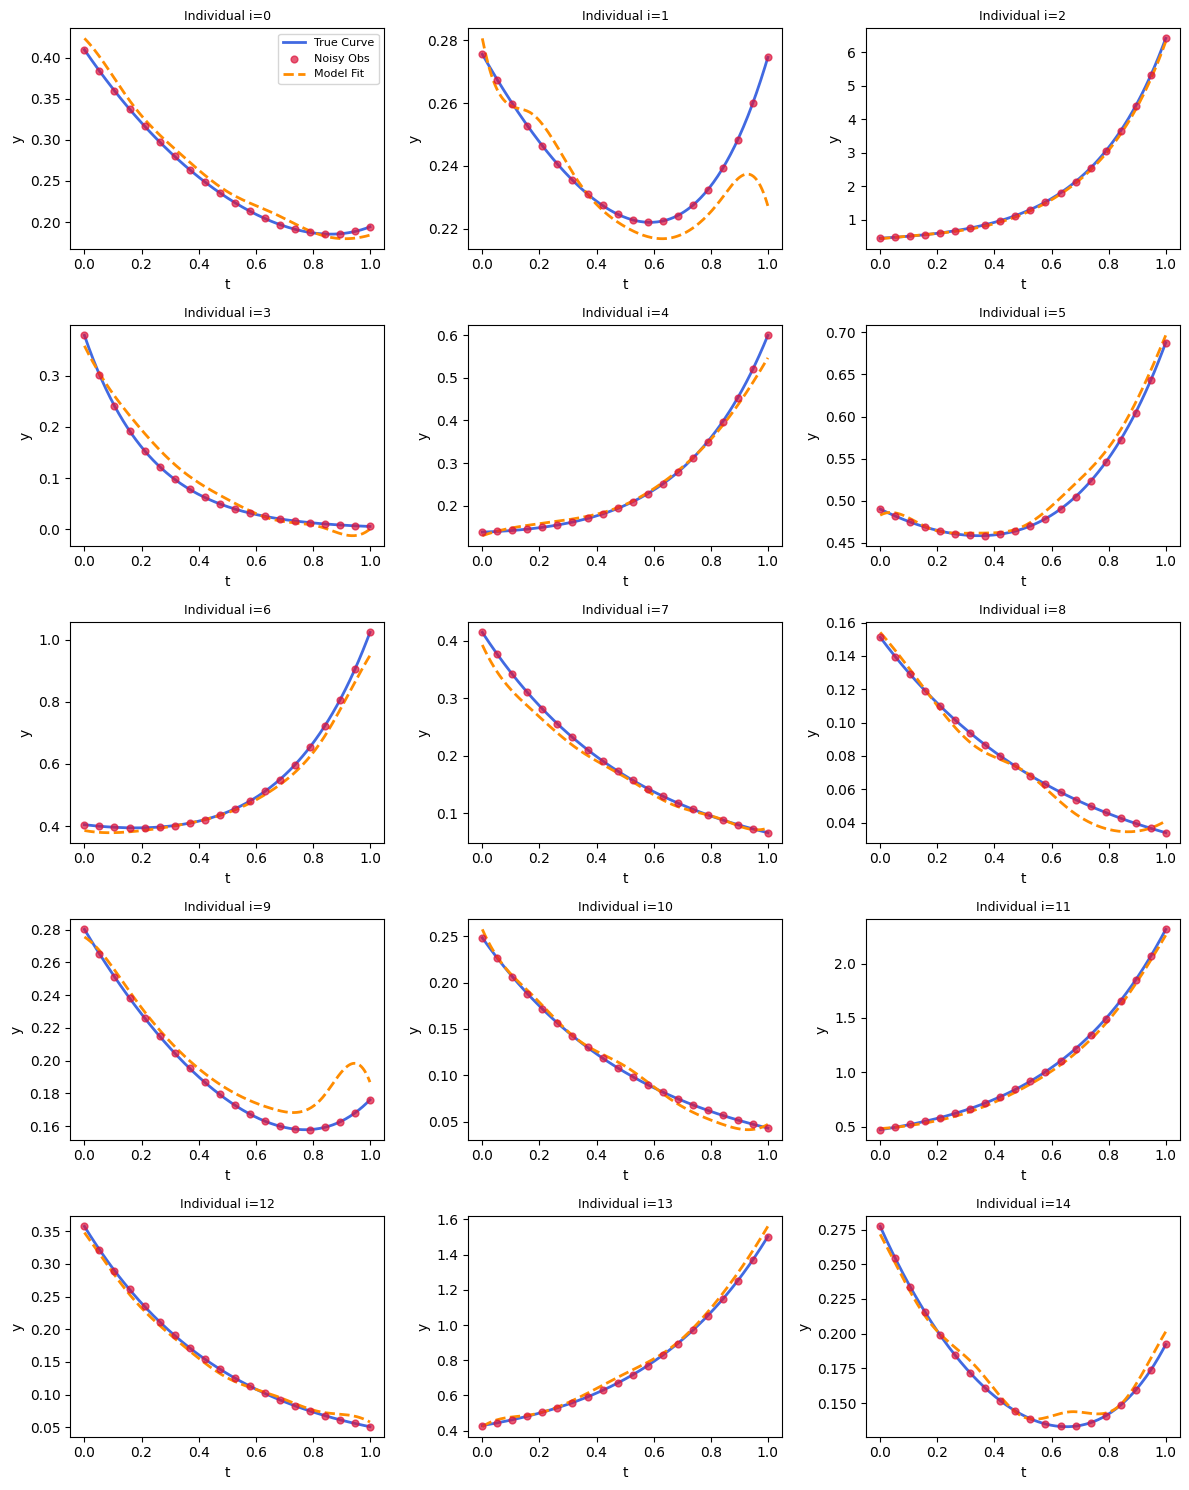

In [9]:
# Plot observations
target_patients = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

plotting_engine = InferenceEngine()
plotting_engine.populate_attributes(
    model=loaded["model"],
    normaliser=loaded["normaliser"],
    basis_functions=loaded["knot_objects"]["basis_functions"],
)

fig = plot_individual_diagnostic(
    dataset=test, 
    indices=target_patients, 
    inference_engine=plotting_engine,
    show_true=True,        # 1. Ground truth
    show_noisy=True,       # 2. Noisy observations
    show_estimated=True,   # 3. Trained model
)
plt.show()

#### Step 4: Compute value-space performance metrics on the test set

In [10]:
evaluator = ModelEvaluator(inference_engine=plotting_engine, test_dataset=test)
value_metrics = evaluator.compute_value_space_accuracy()
print(f"Value-space RMSE: {value_metrics['rmse']:.4f}")
print(f"Value-space R^2:  {value_metrics['r2']:.4f}")


Value-space RMSE: 0.0156
Value-space R^2:  0.9988


#### Step 5a: Compute shape-space perfromance metrics and inspect shape summaries using the naive shape extractor

In [11]:
# Naive shape extraction
UPSILON_1_REL, UPSILON_2_REL = 0.0, 0.0
ZETA_REL, UPSILON_PRUNE_REL, DO_PRUNE = 0.0, 0.0, False

# Initialise an inference engine 
naive_engine = InferenceEngine()
naive_engine.populate_attributes(
    model=loaded["model"],
    normaliser=loaded["normaliser"],
    basis_functions=loaded["knot_objects"]["basis_functions"],
    C=loaded["knot_objects"]["C"],
    breakpoints=loaded["knot_objects"]["breakpoints"],
    zeta_rel=ZETA_REL, 
    upsilon_rel_1=UPSILON_1_REL,
    upsilon_rel_2=UPSILON_2_REL,
    upsilon_rel_prune=UPSILON_PRUNE_REL, 
    do_prune=DO_PRUNE
)

# Get shape-space performance scores
result_naive = evaluate_extraction(naive_engine, test, UPSILON_1_REL, UPSILON_2_REL,
                                UPSILON_PRUNE_REL, DO_PRUNE)

print(f"Exact-sequence-match accuracy: {result_naive['accuracy']:.2f}")
print(f"Mean shape-summary distance:   {result_naive['distance']:.2f}")

Exact-sequence-match accuracy: 0.03
Mean shape-summary distance:   0.12


In [12]:
# Print table of shape summaries for a set of target parients
display(per_patient_table(result_naive, target_patients, test.T))

,patient,true_summary,predicted_summary,match,distance,true_transitions,predicted_transitions
0,0,"[convex_decreasing, convex_increasing]","[concave_decreasing, convex_decreasing, concav...",False,0.108,"[0.0000, 0.8619]","[0.0000, 0.1057, 0.3294, 0.3394, 0.6123, 0.718..."
1,1,"[convex_decreasing, convex_increasing]","[convex_decreasing, concave_decreasing, convex...",False,0.177,"[0.0000, 0.5878]","[0.0000, 0.1320, 0.2838, 0.6302, 0.8480, 0.9285]"
2,2,[convex_increasing],[convex_increasing],True,0.000,[0.0000],[0.0000]
3,3,[convex_decreasing],"[convex_decreasing, concave_decreasing, convex...",False,0.082,[0.0000],"[0.0000, 0.7418, 0.8652, 0.9391]"
4,4,[convex_increasing],"[concave_increasing, convex_increasing]",False,0.073,[0.0000],"[0.0000, 0.2204]"
5,5,"[convex_decreasing, convex_increasing]","[concave_increasing, concave_decreasing, conve...",False,0.127,"[0.0000, 0.3471]","[0.0000, 0.0367, 0.1246, 0.2847, 0.3134, 0.352..."
6,6,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing, concave...",False,0.085,"[0.0000, 0.1800]","[0.0000, 0.0892, 0.9275]"
7,7,[convex_decreasing],"[convex_decreasing, concave_decreasing, convex...",False,0.101,[0.0000],"[0.0000, 0.1639, 0.1809, 0.4425, 0.5481, 0.759..."
8,8,[convex_decreasing],"[concave_decreasing, convex_decreasing, concav...",False,0.195,[0.0000],"[0.0000, 0.1484, 0.4240, 0.5970, 0.8675]"
9,9,"[convex_decreasing, convex_increasing]","[concave_decreasing, convex_decreasing, convex...",False,0.154,"[0.0000, 0.7728]","[0.0000, 0.1362, 0.7312, 0.8672, 0.9458]"


#### Step 5b: Compute shape-space perfromance metrics and inspect shape summaries using the pruned shape extractor

In [13]:
# Pruned shape extraction
ZETA_REL, UPSILON_PRUNE_REL, DO_PRUNE = 1e-6, 0.025, True

# Initialise an inference engine 
pruning_engine = InferenceEngine()
pruning_engine.populate_attributes(
    model=loaded["model"],
    normaliser=loaded["normaliser"],
    basis_functions=loaded["knot_objects"]["basis_functions"],
    C=loaded["knot_objects"]["C"],
    breakpoints=loaded["knot_objects"]["breakpoints"],
    zeta_rel=ZETA_REL, 
    upsilon_rel_1=UPSILON_1_REL,
    upsilon_rel_2=UPSILON_2_REL,
    upsilon_rel_prune=UPSILON_PRUNE_REL, 
    do_prune=DO_PRUNE
)

# Get shape-space performance scores
result_pruned = evaluate_extraction(pruning_engine, test, UPSILON_1_REL, UPSILON_2_REL,
                                UPSILON_PRUNE_REL, DO_PRUNE)

print(f"Exact-sequence-match accuracy: {result_pruned['accuracy']:.2f}")
print(f"Mean shape-summary distance:   {result_pruned['distance']:.2f}")

Exact-sequence-match accuracy: 0.55
Mean shape-summary distance:   0.06


In [14]:
# Print table of shape summaries for a set of target parients
display(per_patient_table(result_pruned, target_patients, test.T))

,patient,true_summary,predicted_summary,match,distance,true_transitions,predicted_transitions
0,0,"[convex_decreasing, convex_increasing]",[convex_decreasing],False,0.092,"[0.0000, 0.8619]",[0.0000]
1,1,"[convex_decreasing, convex_increasing]","[convex_decreasing, concave_decreasing, convex...",False,0.177,"[0.0000, 0.5878]","[0.0000, 0.1320, 0.2838, 0.6302, 0.8480, 0.9285]"
2,2,[convex_increasing],[convex_increasing],True,0.000,[0.0000],[0.0000]
3,3,[convex_decreasing],"[convex_decreasing, convex_increasing]",False,0.041,[0.0000],"[0.0000, 0.9391]"
4,4,[convex_increasing],[convex_increasing],True,0.000,[0.0000],[0.0000]
5,5,"[convex_decreasing, convex_increasing]","[concave_decreasing, convex_decreasing, convex...",False,0.083,"[0.0000, 0.3471]","[0.0000, 0.1246, 0.2847]"
6,6,[convex_increasing],[convex_increasing],True,0.000,[0.0000],[0.0000]
7,7,[convex_decreasing],[convex_decreasing],True,0.000,[0.0000],[0.0000]
8,8,[convex_decreasing],"[convex_decreasing, convex_increasing]",False,0.088,[0.0000],"[0.0000, 0.8675]"
9,9,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing, concave...",False,0.108,"[0.0000, 0.7728]","[0.0000, 0.7312, 0.8672, 0.9458]"
